In [1]:
pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn lifelines

  Preparing metadata (setup.py) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=f48b0894a7a0c085019c7e157ed343ad786b134bf7ff479f7f17a72b17c542ea
  Stored in directory: /Users/mansi/Library/Caches/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np

# Load datasets
orders = pd.read_csv("/Users/mansi/Downloads/Instacart/orders.csv")
order_products = pd.read_csv("/Users/mansi/Downloads/Instacart/order_products__prior.csv")
products = pd.read_csv("/Users/mansi/Downloads/Instacart/products.csv")
departments = pd.read_csv("/Users/mansi/Downloads/Instacart/departments.csv")

#Merging tables
df = order_products.merge(orders, on="order_id", how="left") \
                   .merge(products, on="product_id", how="left") \
                   .merge(departments, on="department_id", how="left")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  department              object 
dtypes: float64(1), int64(10), object(3)
memory usage: 3.4+ GB


In [9]:
# Descriptive Stats: Understand basket size, reorders, customer activity

#Basket size per order
basket_size = df.groupby("order_id")["product_id"].count()
basket_size.describe()


count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: product_id, dtype: float64

In [11]:
#Orders by Customers

orders_per_user = orders.groupby("user_id")["order_id"].count()
orders_per_user.describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64

In [13]:
#Reorder Rate Overall

df["reordered"].mean()

0.5896974667922161

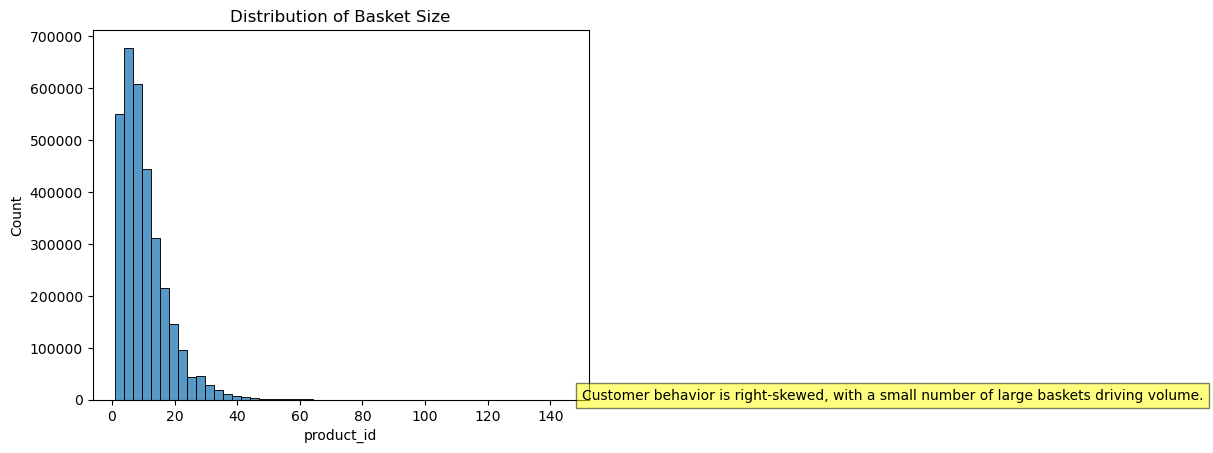

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(basket_size, bins=50)
plt.title("Distribution of Basket Size")
plt.text(150,-0.1, 'Customer behavior is right-skewed, with a small number of large baskets driving volume.', 
        fontsize=10, bbox=dict(facecolor='yellow', alpha=0.5))
plt.show()

In [53]:
#Cohort Analysis: To understand how customer behaviour evolves over time

#Create user Cohort

orders["order_number"] = orders["order_number"].astype(int)

first_order = orders.groupby("user_id")["order_number"].min().reset_index()
first_order.columns = ["user_id", "cohort"]
orders = orders.merge(first_order, on="user_id")
#Retention Matrix

cohort_data = orders.groupby(["cohort", "order_number"])["user_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort", columns="order_number", values="user_id")
cohort_retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
cohort_retention


order_number,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
cohort,,,,,,,,,,,,,,,,,,,,,
1,1.0,1.0,1.0,1.0,0.883681,0.78868,0.710289,0.643124,0.586386,0.53697,...,0.009238,0.008967,0.008632,0.008307,0.008031,0.00772,0.007395,0.007134,0.006891,0.006663


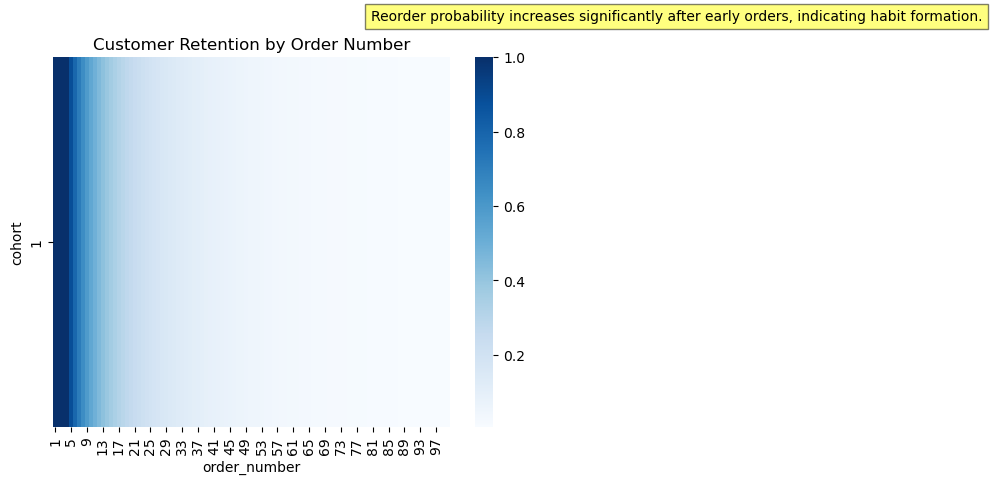

In [57]:
sns.heatmap(cohort_retention, cmap="Blues")
plt.text(80,-0.1, 'Reorder probability increases significantly after early orders, indicating habit formation.', 
        fontsize=10, bbox=dict(facecolor='yellow', alpha=0.5))
plt.title("Customer Retention by Order Number")
plt.show()

In [61]:
#Hypotheses testing
#Do Reorder rates differ by Department?

dept_reorders = df.groupby("department")["reordered"].mean().reset_index()

#ANOVA
from scipy.stats import f_oneway

groups = [df[df["department"] == d]["reordered"] for d in df["department"].unique()]
f_stat, p_value = f_oneway(*groups)
f_stat, p_value


(66250.242215408, 0.0)

In [65]:
#Interpretation of ANOVA

if p_value < 0.05:
    print("Significant difference in reorder rates across departments")
else:
    print("No significant difference")

Significant difference in reorder rates across departments


In [69]:
#Correlation Analysis
#Are popular products also highly reordered?

# Aggregate Product metrics
product_stats = df.groupby("product_id").agg(
    popularity=("order_id", "count"),
    reorder_rate=("reordered", "mean")
).reset_index()

#Correlation 
product_stats[["popularity", "reorder_rate"]].corr()


,popularity,reorder_rate
popularity,1.000000,0.146157
reorder_rate,0.146157,1.000000


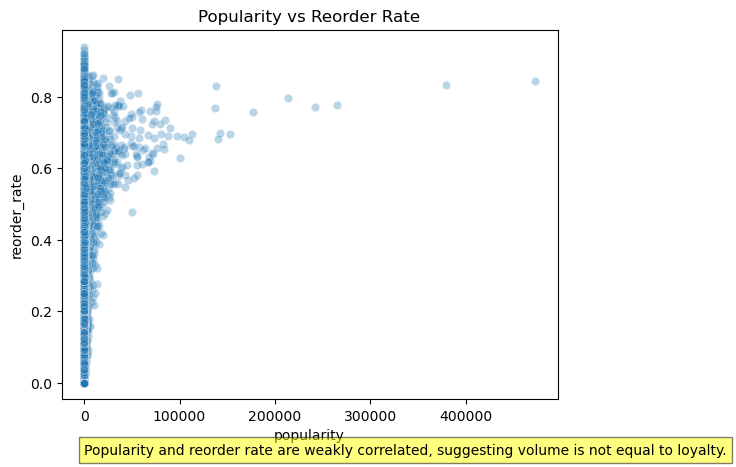

In [79]:
sns.scatterplot(
    data=product_stats,
    x="popularity",
    y="reorder_rate",
    alpha=0.3
)
plt.title("Popularity vs Reorder Rate")
plt.text(150,-0.20, 'Popularity and reorder rate are weakly correlated, suggesting volume is not equal to loyalty.', 
        fontsize=10, bbox=dict(facecolor='yellow', alpha=0.5))
plt.show()


In [87]:
#Logistic Regression: Predict probability of reorder

#Feature selection
features = df[[
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order"
]].fillna(0)

target = df["reordered"]

#Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

#Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [89]:
#Evaluation
from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_prob)

0.7250150756544612

In [93]:
print("Order timing and purchase history significantly increase reorder probability.")

Order timing and purchase history significantly increase reorder probability.


In [109]:
#Customer Churn Analysis: Customer is churned if no orders in the last 30 days

#Total orders per user
user_orders = orders.groupby("user_id")["order_id"].nunique().reset_index()
user_orders.columns = ["user_id", "total_orders"]

#Define Churn using a percentile threshold

threshold = user_orders["total_orders"].quantile(0.20)
user_orders["churned"] = np.where(
    user_orders["total_orders"] <= threshold, 1, 0
)

user_orders["churned"].value_counts(normalize=True)


churned
0    0.78868
1    0.21132
Name: proportion, dtype: float64

In [111]:
#Build churn features (User level)

user_features = df.groupby("user_id").agg(
    total_orders=("order_id", "nunique"),
    avg_basket_size=("product_id", "count"),
    avg_days_between_orders=("days_since_prior_order", "mean")
).reset_index()

churn_df = user_features.merge(
    user_orders[["user_id", "churned"]],
    on="user_id"
)


In [117]:
#Train churn model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
###
#X = churn_df[[
#    "total_orders",
#    "avg_basket_size",
#    "avg_days_between_orders"
#]].fillna(0)

#y = churn_df["churned"]
###

X = churn_df[[
    "avg_basket_size",
    "avg_days_between_orders"
]].fillna(0)

y = churn_df["churned"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])


0.8931441268822542

In [119]:
#Interpret Correlations

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df


,feature,coefficient
1,avg_days_between_orders,0.035484
0,avg_basket_size,-0.042604


In [125]:
print ("Positive coefficient means increases churn risk, Negative coefficient means reduces churn risk")
print ("Customers with longer gaps between orders are significantly more likely to churn, while larger average basket sizes reduce churn risk.")
print ("An initial churn model showed near-perfect performance due to label leakage. After removing label-defining features, the revised model achieved realistic performance and provided interpretable behavioral insights.")

Positive coefficient means increases churn risk, Negative coefficient means reduces churn risk
Customers with longer gaps between orders are significantly more likely to churn, while larger average basket sizes reduce churn risk.
An initial churn model showed near-perfect performance due to label leakage. After removing label-defining features, the revised model achieved realistic performance and provided interpretable behavioral insights.
